# Autocorrect Tool — 01 Exploring the Word-Frequency Model

A spelling corrector needs two things: a **vocabulary** of real words and a **frequency** for each (so that, among several plausible corrections, the most common word wins). We build this from the NLTK Brown corpus. This notebook explores that frequency model.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils

freq=utils.load_frequencies()
print('vocabulary size:',len(freq))
print('total word tokens:',sum(freq.values()))

vocabulary size: 24866
total word tokens: 966336


## 1. Most frequent words

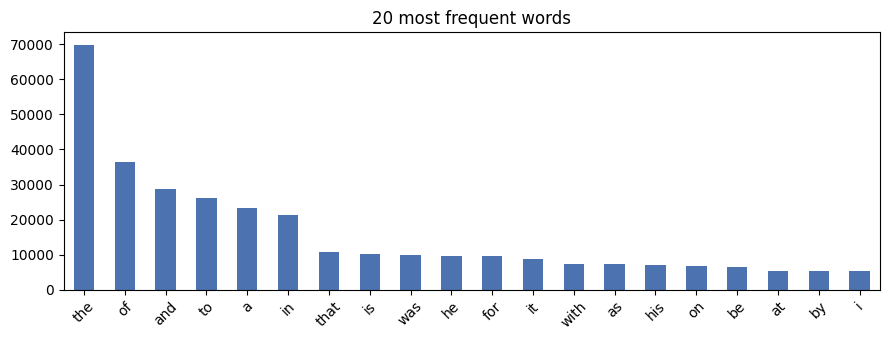

In [2]:
top=pd.Series(dict(freq.most_common(20)))
fig,ax=plt.subplots(figsize=(9,3.5)); top.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('20 most frequent words'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 2. Zipf's law (rank vs frequency)

Natural-language word frequencies follow Zipf's law — a near-straight line on a log-log rank/frequency plot. This is why frequency is such a good prior for ranking corrections.

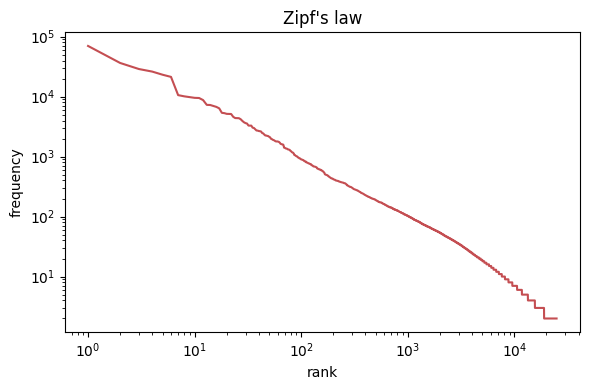

In [3]:
counts=np.array(sorted(freq.values(),reverse=True))
ranks=np.arange(1,len(counts)+1)
fig,ax=plt.subplots(figsize=(6,4)); ax.loglog(ranks,counts,color='#c44e52'); ax.set_xlabel('rank'); ax.set_ylabel('frequency'); ax.set_title("Zipf's law"); plt.tight_layout(); plt.show()

## 3. Word-length distribution

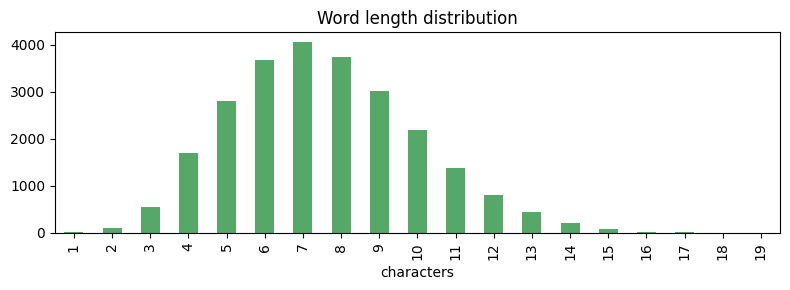

In [4]:
lens=pd.Series([len(w) for w in freq]).value_counts().sort_index()
fig,ax=plt.subplots(figsize=(8,3)); lens.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Word length distribution'); ax.set_xlabel('characters'); plt.tight_layout(); plt.show()

## 4. Summary

- The model holds **~24,900 unique words** with their Brown-corpus counts.
- Frequencies follow Zipf's law — a handful of words dominate, a long tail is rare.
- Notebook 02 uses these frequencies as the prior P(word) in the corrector; notebook 03 evaluates it.